In [3]:
sns.set_theme(style="whitegrid", palette="deep")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
import warnings
warnings.filterwarnings('ignore')
from bs4 import BeautifulSoup

In [4]:
df = pd.read_csv("Final_Dataset.csv")
df

,Brand,Strap_color,Size,Flipkart_assured,Sponsored,Page_num,Price,Original_price,Discount,Price_category,Ratings,Reviews,Promotion_tag
0,Boat,Blue,Free Size,True,True,1,1099,6999,84% off,Budget,4.1,135086,Super Deals
1,Noise,Midnight Blue,Regular,True,True,1,999,5999,83% off,Budget,4.1,883543,Super Deals
2,Noise,Rose Pink,Regular,True,False,1,999,5999,83% off,Budget,4.1,883543,Super Deals
3,Boat,Active Black,Free Size,True,False,1,1099,6999,84% off,Budget,4.1,135086,Super Deals
4,Noise,Jet Black,Regular,True,False,1,999,5999,83% off,Budget,4.1,883543,Super Deals
...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,Goboult,Pure Black,Free Size,True,False,25,1299,7999,83% off,Budget,4.1,8713,Upto ₹300 Off on Exchange
992,Fire,Milange Grey,Free Size,True,True,25,1299,9999,87% off,Budget,4.1,335485,Upto ₹300 Off on Exchange
993,Gamesir,Pink,Free Size,True,True,25,695,1999,65% off,Budget,3.7,218,Bank Offer
994,Fire,Gold Black,Free Size,True,False,25,2799,21000,86% off,Mid-Range,4.1,41025,Upto ₹300 Off on Exchange


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="pastel"
)


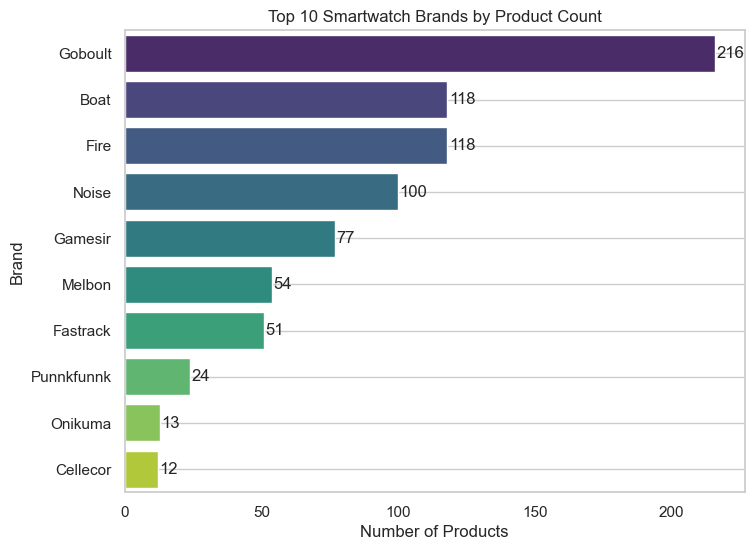

In [6]:
plt.figure(figsize=(8,6))

top_brands = df["Brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="viridis"
)

plt.title("Top 10 Smartwatch Brands by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Brand")

for i, v in enumerate(top_brands.values):
    plt.text(v + 0.5, i, str(v), va='center')

plt.grid()
plt.show()


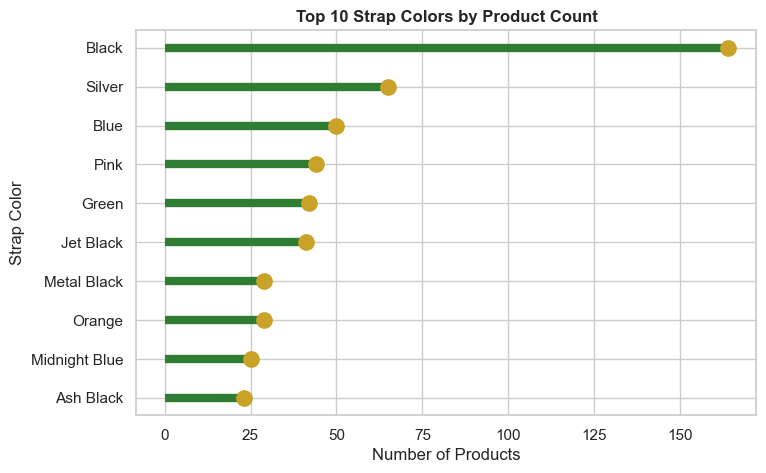

In [8]:
plt.figure(figsize=(8,5))

colors = df["Strap_color"].value_counts().head(10).sort_values()

plt.hlines(
    y=colors.index,
    xmin=0,
    xmax=colors.values,
    linewidth=6,
    color="#2E7D32"   # dark green
)

plt.plot(
    colors.values,
    colors.index,
    "o",
    markersize=11,
    color="#C9A227"   # dark yellow
)

plt.title("Top 10 Strap Colors by Product Count", weight="bold")
plt.xlabel("Number of Products")
plt.ylabel("Strap Color")

plt.show()


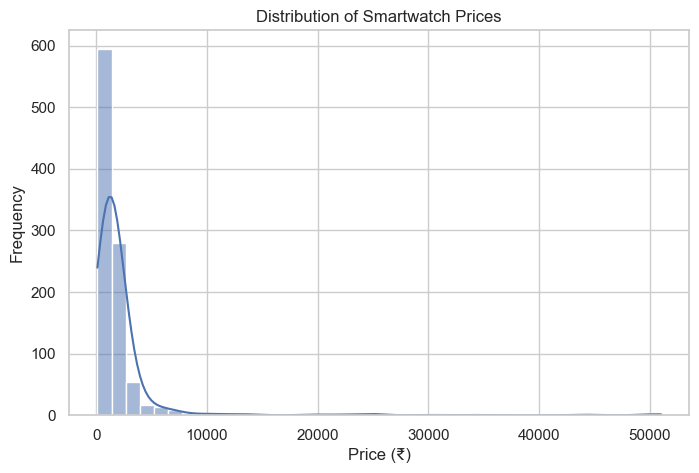

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of Smartwatch Prices")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")

plt.show()


In [10]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['Price'] < q1 - 1.5 * iqr) | (df['Price'] > q3 + 1.5 * iqr)]
outliers

,Brand,Strap_color,Size,Flipkart_assured,Sponsored,Page_num,Price,Original_price,Discount,Price_category,Ratings,Reviews,Promotion_tag
36,Beatxp,Electric Black,Free Size,False,False,1,6499,6999,84% off,Premium,4.1,146012,Only 3 left
45,Samsung,Gray,Free Size,True,False,2,3499,9999,65% off,Mid-Range,4.4,23221,Upto ₹300 Off on Exchange
129,Huawei,Pink,Free size,True,False,4,3099,6499,52% off,Mid-Range,4.4,114,Super Deals
152,Fire,Ocean Drip Dark Grey Halo solid,Free Size,False,False,4,11999,19999,40% off,Luxury,3.9,3373,Bank Offer
156,Boat,Steel Black,Free Size,True,True,4,3299,9499,65% off,Mid-Range,4.2,1237,Super Deals
...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,Fastrack,Black,Free Size,True,False,25,3499,8995,61% off,Mid-Range,4.3,183,Upto ₹300 Off on Exchange
970,Samsung,Black,Large,True,False,25,50999,59999,15% off,Ultra-Luxury,4.5,147,Upto ₹300 Off on Exchange
975,Motorola,Pantone Parachute Purple Band,Free Size,False,False,25,5999,11999,50% off,Premium,4.1,109,Super Deals
988,Google,Obsidian,Free Size,True,False,25,43900,6999,84% off,Luxury,4.5,42,Upto ₹300 Off on Exchange


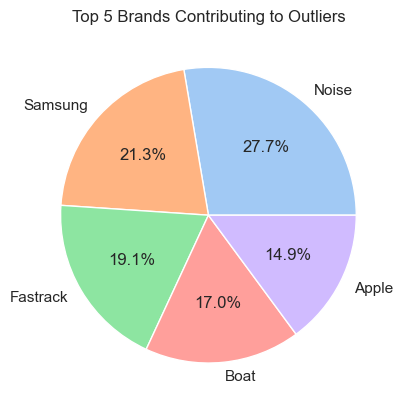

In [11]:
top_outlier_brands = outliers['Brand'].value_counts().head(5)
plt.figure()
plt.pie(top_outlier_brands, labels=top_outlier_brands.index, autopct='%1.1f%%')
plt.title("Top 5 Brands Contributing to Outliers")
plt.show()

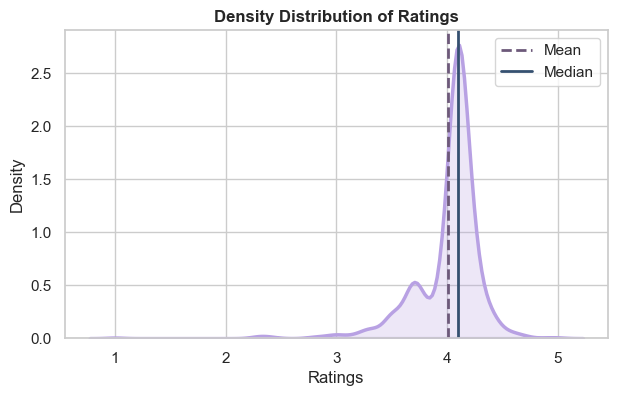

In [12]:
plt.figure(figsize=(7,4))

sns.kdeplot(
    df["Ratings"],
    fill=True,
    color="#B8A1E3",
    linewidth=2.5
)

mean_val = df["Ratings"].mean()
median_val = df["Ratings"].median()

plt.axvline(mean_val, linestyle="--", linewidth=2, color="#6D597A", label="Mean")
plt.axvline(median_val, linestyle="-", linewidth=2, color="#355070", label="Median")

plt.title("Density Distribution of Ratings", weight="bold")
plt.xlabel("Ratings")
plt.ylabel("Density")
plt.legend()

plt.show()


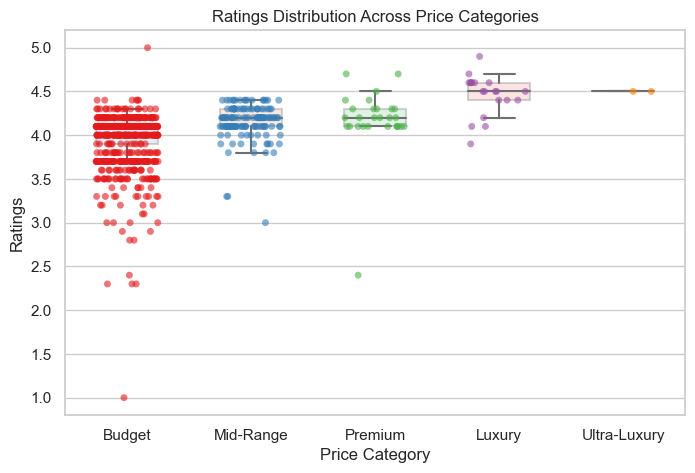

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Price_category',
    y='Ratings',
    data=df,
    width=0.5,
    showfliers=False,
    boxprops=dict(alpha=0.3)
)

sns.stripplot(
    x='Price_category',
    y='Ratings',
    data=df,
    jitter=0.25,
    alpha=0.6,
    palette="Set1"
)

plt.title("Ratings Distribution Across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Ratings")

plt.show()


<Axes: xlabel='Sponsored', ylabel='count'>

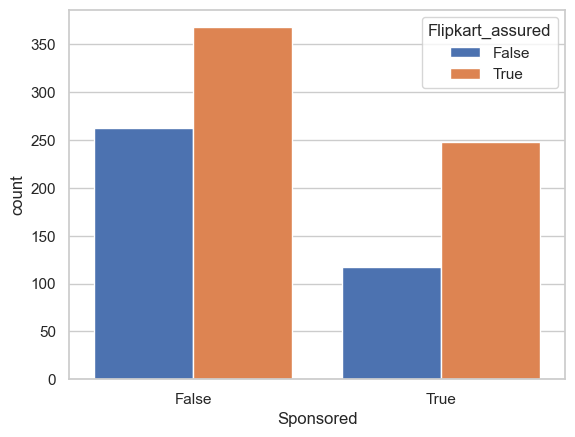

In [14]:
sns.countplot(
    data=df,
    x="Sponsored",
    hue="Flipkart_assured",
    palette="deep",
    saturation=1   # ← here, not in set_theme
)


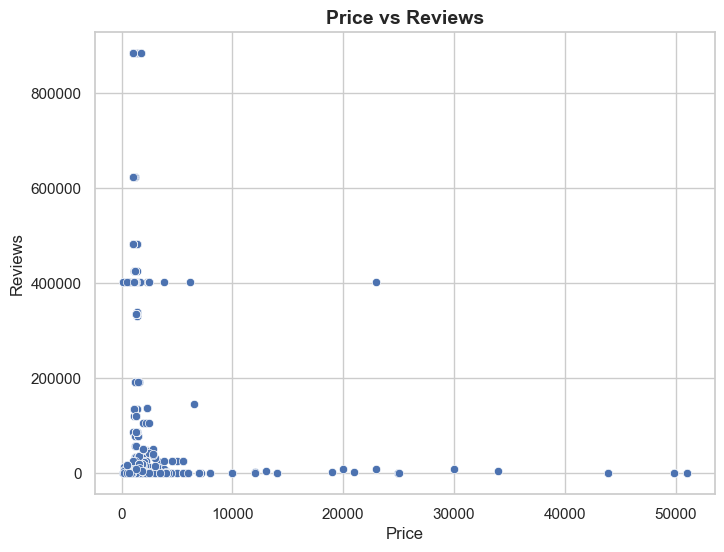

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='Price', y='Reviews')

plt.title("Price vs Reviews", fontsize=14, weight='bold')
plt.xlabel("Price")
plt.ylabel("Reviews")
plt.show()

In [16]:
top10_brands = df["Brand"].value_counts().head(10).index.tolist()

df_top10 = df[df["Brand"].isin(top10_brands)].copy()


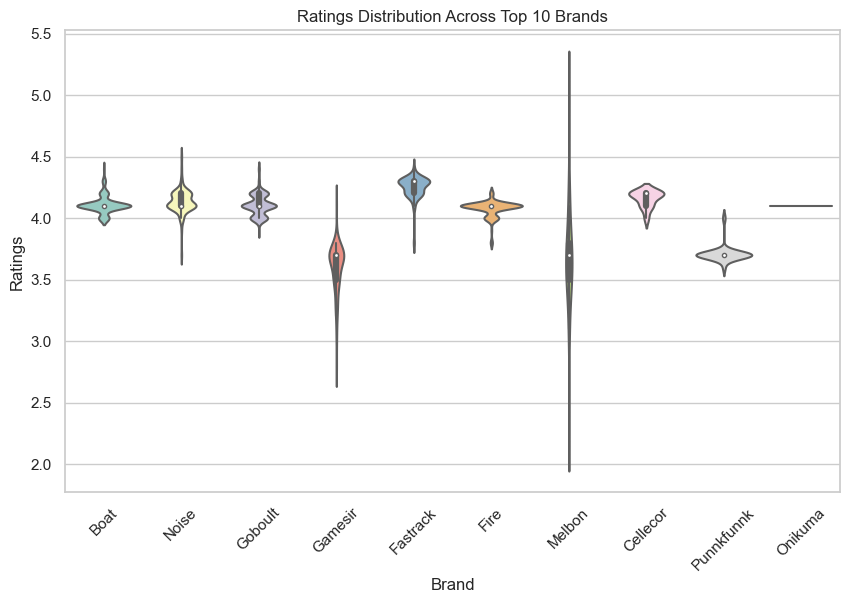

In [17]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_top10,
    x='Brand',
    y='Ratings',
    palette="Set3"
)

plt.xticks(rotation=45)
plt.title("Ratings Distribution Across Top 10 Brands")

plt.show()


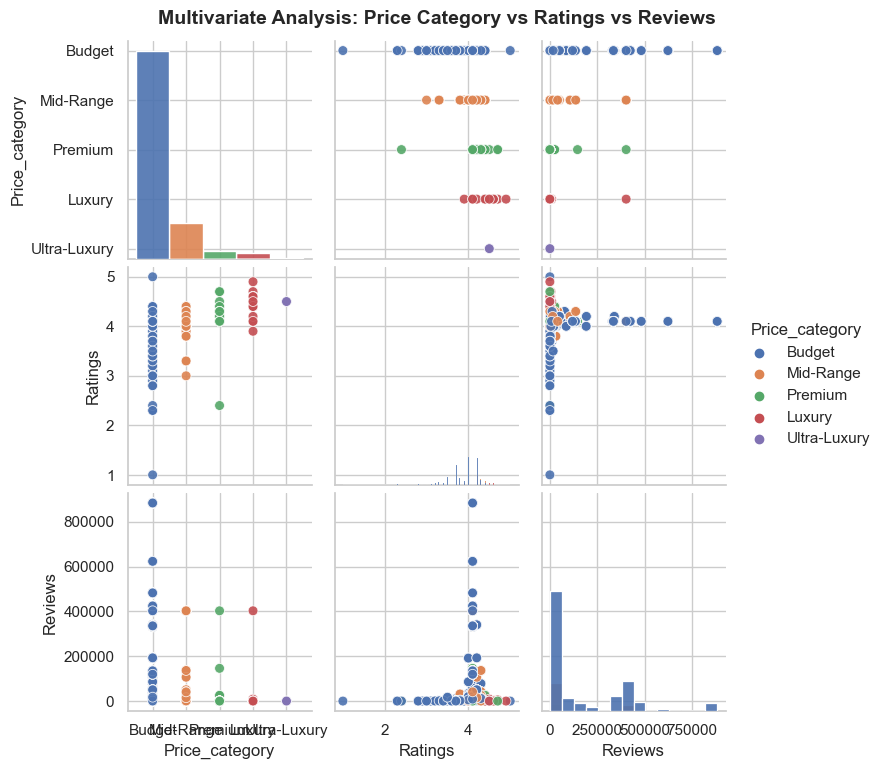

In [23]:
sns.set_theme(style="whitegrid", palette="deep")

g = sns.pairplot(
    df,
    vars=["Price_category", "Ratings", "Reviews"],
    hue="Price_category",
    diag_kind="hist",
    palette="deep",
    plot_kws={"s":50, "alpha":0.9},
    diag_kws={"alpha":0.9, "edgecolor":"white"}
)

g.fig.suptitle(
    "Multivariate Analysis: Price Category vs Ratings vs Reviews",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.show()

g = sns.pairplot(
    df,
    vars=['Price_category', 'Ratings', 'Reviews'],
    hue='Price_category',
    diag_kind='hist'
)

g.fig.suptitle("Multivariate Analysis: Price Category vs Ratings vs Reviews",
               y=1.02, fontsize=14)

plt.show()

Text(0.5, 1.0, 'Correlation Between Price, Ratings, and Reviews')

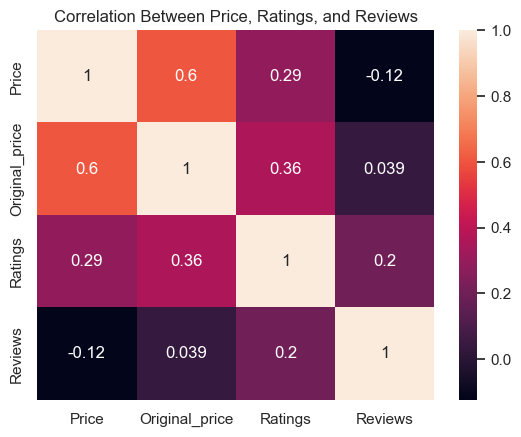

In [26]:

sns.heatmap(df[['Price','Original_price','Ratings','Reviews']].corr(), annot=True)
plt.title("Correlation Between Price, Ratings, and Reviews")

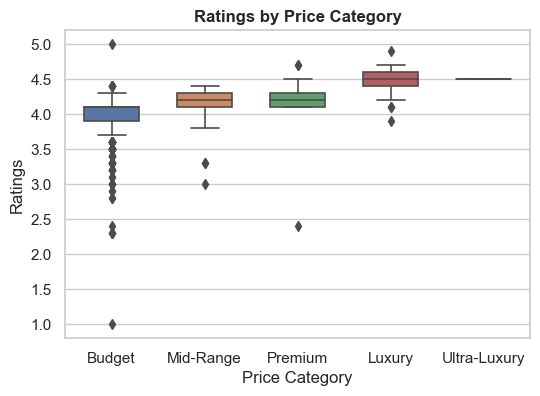

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Price_category",
    y="Ratings",
    data=df,
    palette="deep",
    width=0.6,
    linewidth=1.2
)

plt.title("Ratings by Price Category", weight="bold")
plt.xlabel("Price Category")
plt.ylabel("Ratings")

plt.show()